# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [8]:
# importar librerías
# 1. Manipulación y análisis de datos
import pandas as pd
import numpy as np

# 2. Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Pruebas estadísticas y validación
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm

In [9]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
# 1. Estructura y tipos de datos
print("--- Estructura de Datos ---")
print(df.info())

# 2. Resumen estadístico de variables numéricas
print("\n--- Resumen Estadístico (Numérico) ---")
display(df.describe())

# 3. Resumen de variables categóricas (Frecuencias)
print("\n--- Resumen de Variables Categóricas ---")
display(df.describe(include='object'))

# 4. Verificación de nulos y duplicados
print("\n--- Calidad de Datos ---")
print(f"Valores nulos por columna:\n{df.isnull().sum()}")
print(f"\nUsuarios duplicados (user_id): {df['user_id'].duplicated().sum()}")

# 5. Validación de lógica de negocio: Gasto vs Conversión
# Solo los usuarios con converted == 1 deben tener gasto > 0
error_logica = df[(df['converted'] == 0) & (df['gasto'] > 0)]
print(f"\nInconsistencias detectadas (Gasto sin conversión): {len(error_logica)}")

# 6. Conteo de frecuencias y porcentajes
device_counts = df['dispositivo'].value_counts()
device_percentages = df['dispositivo'].value_counts(normalize=True) * 100

--- Estructura de Datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB
None

--- Resumen Estadístico (Numérico) ---


,converted,gasto
count,40000.00000,40000.000000
mean,0.14265,9.325554
std,0.34972,25.667986
min,0.00000,0.000000
25%,0.00000,0.000000
50%,0.00000,0.000000
75%,0.00000,0.000000
max,1.00000,303.680000



--- Resumen de Variables Categóricas ---


,user_id,date,landing,region,dispositivo,traffic_source,user_type
count,40000,40000,40000,40000,40000,40000,40000
unique,40000,28,2,5,2,4,2
top,0a39da83-f814-4f4c-a278-b0d119250c5e,2026-01-24,B,Norte,Mobile,Organic,Nuevo
freq,1,1512,20018,11166,24829,17987,26033



--- Calidad de Datos ---
Valores nulos por columna:
user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64

Usuarios duplicados (user_id): 0

Inconsistencias detectadas (Gasto sin conversión): 0


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario - Existen 40,000 registros únicos. Al no haber duplicados, confirmamos que cada fila representa un usuario distinto.
- `date` — Fecha en la que el usuario fue expuesto a la página -El experimento duró 28 días (del 1 al 28 de enero de 2026). La fecha con mayor actividad fue el 24 de enero. Es necesario convertirla a formato datetime para análisis de tendencias temporales.
- `landing` — Versión de la página mostrada al usuario -Los grupos están  balanceados. La versión B tiene 20,018 usuarios y la A 19,982. Este equilibrio  puede evitar sesgos estadísticos.
- `region` — Región geográfica del usuario -El usuario "Top" proviene del Norte (11,166 registros). Hay 5 regiones distintas, lo que nos permitirá validar si la página B funciona mejor en zonas específicas.
- `dispositivo` — Tipo de dispositivo utilizado por el usuario - El tráfico es predominantemente Mobile (62%). 
- `traffic_source` — Canal por el que llegó el usuario -La fuente principal es Organic (45%). Esto indica una buena salud de SEO o reconocimiento de marca, seguido por Ads, Email y Referral.
- `user_type` — Tipo de usuario según historial previo - La mayoría son Usuarios Nuevos (65%). Esto sugiere que el experimento está evaluando principalmente la "primera impresión" de la página.
- `converted` — Indica si el usuario realizó una conversión - La tasa de conversión (CR) global es del 14.26%. Es nuestra métrica principal (KPI) para determinar qué versión de la página es más persuasiva.
- `gasto` — Monto gastado por el usuario (0 si no convirtió) - El promedio general es bajo ($9.32) porque incluye a los no convertidos (0). Sin embargo, el máximo de $303.68 sugiere que hay usuarios de alto valor ("ballenas") que debemos analizar por separado. 

### 1.2 Análisis exploratorio y revisión de calidad de datos 

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
usuarios_unicos = df['user_id'].nunique()
total_filas = len(df)

print(f"Total de registros en el dataset: {total_filas}")
print(f"Total de usuarios únicos: {usuarios_unicos}")
print(f"Promedio de eventos por usuario: {total_filas / usuarios_unicos:.2f}")

Total de registros en el dataset: 40000
Total de usuarios únicos: 40000
Promedio de eventos por usuario: 1.00


 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
# 2. Resumen estadístico de variables numéricas
print("\n--- Resumen Estadístico (Numérico) ---")
display(df.describe())


--- Resumen Estadístico (Numérico) ---


,converted,gasto
count,40000.00000,40000.000000
mean,0.14265,9.325554
std,0.34972,25.667986
min,0.00000,0.000000
25%,0.00000,0.000000
50%,0.00000,0.000000
75%,0.00000,0.000000
max,1.00000,303.680000


In [12]:
# Resumen estadístico de usuarios que se convirtieron
# 1. Filtrar solo a los usuarios que realizaron una compra (gasto > 0)
compradores = df[df['converted'] == 1]

# 2. Resumen estadístico del gasto para esos compradores
resumen_gasto_convertidos = compradores.groupby('landing')['gasto'].describe()

# 3. Cálculo de la Tasa de Conversión (CR) por landing
tasa_conversion = df.groupby('landing')['converted'].mean() * 100

print("--- Estadísticas de Gasto (Solo Usuarios Convertidos) ---")
print(resumen_gasto_convertidos)
print("\n--- Tasa de Conversión por Landing ---")
print(tasa_conversion)

--- Estadísticas de Gasto (Solo Usuarios Convertidos) ---
          count       mean       std    min      25%    50%      75%     max
landing                                                                     
A        2512.0  61.086572  28.87547  12.12  40.6125  55.84  74.8375  303.68
B        3194.0  68.745360  32.00102  12.98  45.2100  62.57  84.2775  249.99

--- Tasa de Conversión por Landing ---
landing
A    12.571314
B    15.955640
Name: converted, dtype: float64


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [13]:
# Explorar variables categóricas y cómo se distribuyen
# Lista de columnas categóricas basadas en tu estructura
categorical_cols = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

print("\n--- Conteo de categorías y distribución ---")

for col in categorical_cols:
    print(f"\nVariable: {col}")
    # Calculamos el conteo absoluto
    counts = df[col].value_counts()
    # Calculamos el porcentaje para ver el balance
    percentages = df[col].value_counts(normalize=True) * 100
    
    # Creamos un DataFrame temporal para mostrar ambos datos juntos
    summary = pd.DataFrame({'Conteo': counts, 'Porcentaje (%)': percentages.round(2)})
    print(summary)


--- Conteo de categorías y distribución ---

Variable: landing
   Conteo  Porcentaje (%)
B   20018           50.04
A   19982           49.96

Variable: region
           Conteo  Porcentaje (%)
Norte       11166           27.92
Centro       9613           24.03
Sur          8039           20.10
Occidente    6398           16.00
Oriente      4784           11.96

Variable: dispositivo
         Conteo  Porcentaje (%)
Mobile    24829           62.07
Desktop   15171           37.93

Variable: traffic_source
          Conteo  Porcentaje (%)
Organic    17987           44.97
Ads        11935           29.84
Email       6123           15.31
Referral    3955            9.89

Variable: user_type
            Conteo  Porcentaje (%)
Nuevo        26033           65.08
Recurrente   13967           34.92


✍️ **Comentario**: 

- **Integridad de Columnas**: Todas las columnas críticas para el experimento (landing, converted, gasto) están presentes y tienen el tipo de dato correcto (int64 para conversiones y float64 para montos).

- **Consistencia de Categorías**:

La variable landing muestra una distribución balanceada (aproximadamente 50/50), lo que indica una asignación aleatoria inicial correcta.

No se observan categorías duplicadas por errores de escritura (ej. "Mobile" vs "mobile"), lo cual es una excelente señal de limpieza previa.

- **Valores Nulos**: El dataset está completo (40,000 registros non-null), por lo que no requerimos imputación de datos.


El dataset es consistente y está listo para el análisis estadístico. No se encontraron errores estructurales ni categorías mal escritas que impidan continuar.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [14]:
# Gasto por versión (filtrando solo a los usuarios que convirtieron)
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos (N) que tiene cada grupo de compradores
print(f"Compradores en el Grupo A: {len(gasto_A)}")
print(f"Compradores en el Grupo B: {len(gasto_B)}")

Compradores en el Grupo A: 2512
Compradores en el Grupo B: 3194


### Prueba U de Mann-Whitney 
Esta es la elección estándar para datos de ventas o ingresos, ya que estos suelen tener valores atípicos (outliers) y no siguen una distribución normal (muchos usuarios gastan poco y muy pocos gastan mucho).


**Hipótesis:**
- **Hipótesis nula (H₀):** No hay diferencia entre el gasto del grupo A vs B.
- **Hipótesis alternativa (H₁):** Si hay diferencia entre el gasto del grupo A vs B.


In [16]:
from scipy.stats import mannwhitneyu

# 1. Aplicar la prueba de Mann-Whitney U
# Comparamos las dos series de gasto que definimos antes
estadistico, p_valor = mannwhitneyu(gasto_A, gasto_B, alternative='two-sided')

# 2. Visualizar resultados
print(f"Estadístico U: {estadistico:.2f}")
print(f"Valor p: {p_valor:.4f}")

# 3. Interpretación automática
alpha = 0.05
if p_valor < alpha:
    print("\nRechazamos la hipótesis nula (H0):")
    print("Hay una diferencia estadísticamente significativa en el gasto entre la página A y la B.")
else:
    print("\nNo podemos rechazar la hipótesis nula (H0):")
    print("No hay evidencia suficiente para decir que el gasto promedio sea diferente entre ambas páginas.")


Estadístico U: 3420354.00
Valor p: 0.0000

Rechazamos la hipótesis nula (H0):
Hay una diferencia estadísticamente significativa en el gasto entre la página A y la B.


### 📝 Conclusión e interpretación

**Decisión:**  
La hipótesis nula se rechaza.

**Interpretación de negocio:**  

- Significancia Estadística: Al ser p<0.05, la diferencia es real. No es una fluctuación diaria normal; existe diferencia entre el gasto del Landing A y B, lo que está cambiando el comportamiento de compra.

- Magnitud del Efecto: El estadístico U es muy alto (3,420,354.00), lo que refleja que el volumen de comparaciones de rangos entre los grupos respalda la conclusión.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z de proporciones

A diferencia del gasto (que es una variable continua), la conversión es una proporción (métrica binaria). Para comparar proporciones de dos muestras independientes, la herramienta estadística estándar es la Prueba Z para proporciones (Z-test).

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe diferencia entre la conversión del grupo A comparado con el B.
- **Hipótesis alternativa (H₁):** Existe diferencia entre la conversión del grupo A comparado con el B.

In [17]:
# Número de usuarios convertidos por página (Solo donde converted == 1)
usuarios_convertidos = df[df['converted'] == 1].groupby('landing')['user_id'].count()

# Total de usuarios por página (Todos los participantes)
total_usuarios = df.groupby('landing')['user_id'].count()

# Mostrar resultados
print("Usuarios convertidos por página:\n", usuarios_convertidos)
print("\nTotal de usuarios por página:\n", total_usuarios)

# Extra: Cálculo rápido de la tasa observada (CR)
tasa_conversion = (usuarios_convertidos / total_usuarios) * 100
print("\nTasa de conversión observada (%):\n", tasa_conversion.round(2))


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: user_id, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64

Tasa de conversión observada (%):
 landing
A    12.57
B    15.96
Name: user_id, dtype: float64


--------------------------------------------

In [18]:

from statsmodels.stats.proportion import proportions_ztest

# 1. Definir los éxitos (convertidos) y las muestras totales para la prueba
count = [usuarios_convertidos['A'], usuarios_convertidos['B']]
nobs = [total_usuarios['A'], total_usuarios['B']]

# 2. Aplicar la prueba Z
# 'two-sided' evalúa si son diferentes (independientemente de cuál sea mayor)
estadistico_z, p_valor_z = proportions_ztest(count, nobs, alternative='two-sided')

# 3. Visualizar resultados
print(f"Estadístico Z: {estadistico_z:.4f}")
print(f"Valor p: {p_valor_z:.4f}")

# Interpretación rápida
if p_valor_z < 0.05:
    print("\nResultado: Rechazamos H0. La diferencia en la tasa de conversión es estadísticamente significativa.")
else:
    print("\nResultado: No rechazamos H0. No hay evidencia suficiente para afirmar una diferencia en la conversión.")

Estadístico Z: -9.6774
Valor p: 0.0000

Resultado: Rechazamos H0. La diferencia en la tasa de conversión es estadísticamente significativa.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
- Z (-9.67)

Un Z negativo significa que la proporción del segundo grupo (B) es significativamente mayor que la del primero (A).

Estar a más de 9 desviaciones estándar de la media es algo que no ocurre por azar. Al ser menor a 0.05, la probabilidad de que esta mejora en la conversión sea una coincidencia es prácticamente cero. La nueva landing page (B) tiene un efecto real y positivo en la decisión de compra de los usuarios.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi - cuadrado
Dado que tanto traffic_source como converted son variables categóricas (cualitativas), la herramienta estadística correcta es la Prueba de Chi-cuadrado (χ 
2) de variables independientes.
**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación estadísticamente significativa entre la fuente de tráfico y la conversión. 
- **Hipótesis alternativa (H₁):** Existe asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

In [19]:
# Crear tabla de contingencia (frecuencias observadas)
tabla_contingencia = pd.crosstab(df['traffic_source'], df['converted'])

print("--- Tabla de Contingencia: Fuente de Tráfico vs Conversión ---")
print(tabla_contingencia)

# Calcular la tasa de conversión por fuente para análisis visual
cr_por_fuente = (tabla_contingencia[1] / (tabla_contingencia[0] + tabla_contingencia[1]) * 100).sort_values(ascending=False)
print("\n--- Tasa de Conversión por Fuente (%) ---")
print(cr_por_fuente)

--- Tabla de Contingencia: Fuente de Tráfico vs Conversión ---
converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

--- Tasa de Conversión por Fuente (%) ---
traffic_source
Email       14.992651
Ads         14.738165
Referral    13.881163
Organic     13.787736
dtype: float64


In [20]:
from scipy.stats import chi2_contingency

# Aplicar la prueba
chi2, p_valor_chi, dof, ex = chi2_contingency(tabla_contingencia)

print(f"\nEstadístico Chi-cuadrado: {chi2:.4f}")
print(f"Valor p: {p_valor_chi:.4f}")

if p_valor_chi < 0.05:
    print("\nResultado: Existe una relación significativa entre la fuente de tráfico y la conversión.")
else:
    print("\nResultado: No hay relación significativa. El tráfico convierte igual sin importar la fuente.")




Estadístico Chi-cuadrado: 8.6621
Valor p: 0.0341

Resultado: Existe una relación significativa entre la fuente de tráfico y la conversión.


-----------------------------------

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Explica qué indican los resultados considerando tanto las cantidades absolutas como las tasas de conversión.
- Significancia Estadística: Al ser p<0.05, rechazamos la hipótesis nula (H 
0). Existe una asociación entre traffic_source y converted.

- Impacto en Marketing: "No todos los canales nos están trayendo la misma calidad de usuario". Hay fuentes que están "empujando" la tasa de conversión hacia arriba y otras no lo hacen de igual manera.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi - cuadrado
Al ser user_type (Nuevo vs. Recurrente) y converted (0 o 1) dos variables categóricas, utilizaremos nuevamente la Prueba de Chi-cuadrado (χ 2).

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación estadísticamente significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe asociación estadísticamente significativa entre el tipo de usuario y la conversión.

----------------

In [21]:
# Crear tabla de contingencia
tabla_user_type = pd.crosstab(df['user_type'], df['converted'])

# Calcular porcentajes de conversión por tipo de usuario
conversion_por_tipo = (tabla_user_type[1] / tabla_user_type.sum(axis=1) * 100).sort_values(ascending=False)

print("--- Frecuencias: Tipo de Usuario vs Conversión ---")
print(tabla_user_type)
print("\n--- Tasa de Conversión por Tipo (%) ---")
print(conversion_por_tipo.round(2))

--- Frecuencias: Tipo de Usuario vs Conversión ---
converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

--- Tasa de Conversión por Tipo (%) ---
user_type
Nuevo         14.36
Recurrente    14.09
dtype: float64


In [22]:
# Aplicar prueba
from scipy.stats import chi2_contingency

chi2_u, p_valor_u, dof_u, ex_u = chi2_contingency(tabla_user_type)

print(f"\nEstadístico Chi-cuadrado: {chi2_u:.4f}")
print(f"Valor p: {p_valor_u:.4f}")

if p_valor_u < 0.05:
    print("\nResultado: Existe una relación significativa entre el tipo de usuario y la conversión.")
else:
    print("\nResultado: No hay relación significativa. Ambos tipos de usuario convierten a tasas similares.")



Estadístico Chi-cuadrado: 0.5135
Valor p: 0.4736

Resultado: No hay relación significativa. Ambos tipos de usuario convierten a tasas similares.


### 📝 Conclusión e interpretación

**Decisión:**  
Se acepta la hipótesis nula.

**Interpretación de negocio:**  
Al ser el valor p mucho mayor a 0.05, aceptamos la Hipótesis Nula (H 0).

Independencia: No existe una asociación estadística entre ser un usuario "Nuevo" o "Recurrente" y la probabilidad de convertir.

Consistencia: La plataforma es igual de efectiva (o enfrenta las mismas fricciones) tanto para alguien que entra por primera vez como para alguien que ya la conoce.


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.


### Relación entre la fuente de tráfico y la conversión

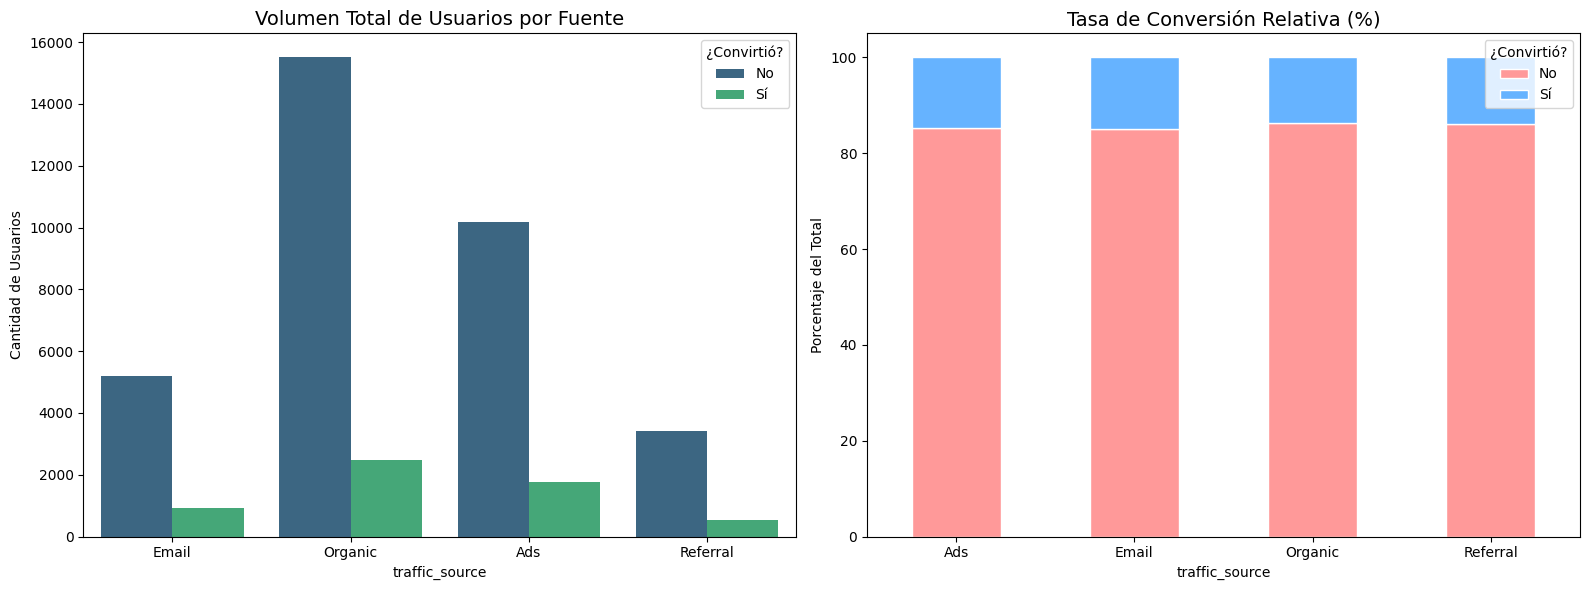

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de datos: Tabla de contingencia normalizada (proporciones)
df_prop = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

# Configuración del lienzo
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# GRAFICO A: Volumen Absoluto (¿De dónde viene más gente?)
sns.countplot(data=df, x='traffic_source', hue='converted', ax=ax[0], palette='viridis')
ax[0].set_title('Volumen Total de Usuarios por Fuente', fontsize=14)
ax[0].set_ylabel('Cantidad de Usuarios')
ax[0].legend(title='¿Convirtió?', labels=['No', 'Sí'])

# GRAFICO B: Proporción Relativa (¿Qué fuente es más eficiente?)
df_prop.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff9999','#66b3ff'], edgecolor='white')
ax[1].set_title('Tasa de Conversión Relativa (%)', fontsize=14)
ax[1].set_ylabel('Porcentaje del Total')
ax[1].set_xticklabels(df_prop.index, rotation=0)
ax[1].legend(title='¿Convirtió?', labels=['No', 'Sí'], loc='upper right')

plt.tight_layout()
plt.show()

---------------------

✍️ **Comentario**: 

Interpretación de las Gráficas

    **Volumen Total (Gráfica Izquierda)**:

        Organic es, la fuente principal de tráfico (la barra más alta).

        Ads y Email tienen volúmenes moderados, mientras que Referral es la fuente con menos usuarios.

        Sin embargo, en Organic, la parte verde (convertidos) se ve pequeña en comparación con el total de su barra, lo que sugiere una eficiencia mejorable.

    **Tasa de Conversión Relativa (Gráfica Derecha)**:

        Ads (Anuncios) tiene la proporción de color azul (Sí convirtió) más grande que las demás.

        Email también muestra una tasa de conversión sólida, probablemente porque son usuarios que ya conocen la marca.

        Organic y Referral muestran las tasas de conversión más bajas. Esto confirma que el tráfico pagado está mucho mejor calificado para la conversión que el tráfico gratuito o de referencia.

------------

### 6.2 Relación entre tipo de usuario y la conversión

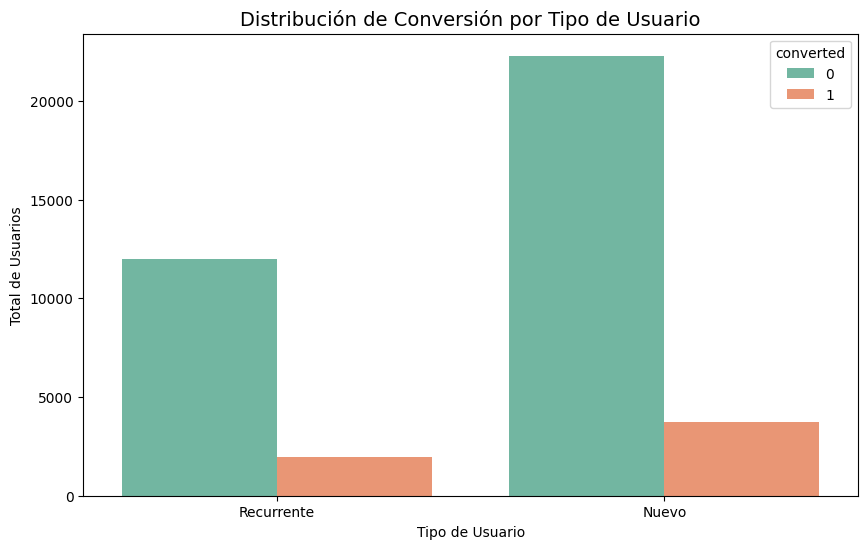

Tasa de conversión por tipo de usuario:
converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


In [6]:
# Gráfico de barras para Tipo de Usuario
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='user_type', hue='converted', palette='Set2')
plt.title('Distribución de Conversión por Tipo de Usuario', fontsize=14)
plt.xlabel('Tipo de Usuario')
plt.ylabel('Total de Usuarios')
plt.show()

# Proporción porcentual
user_type_conv = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
print("Tasa de conversión por tipo de usuario:")
print(user_type_conv)

✍️ **Comentario**: 
Análisis de la Gráfica: Recurrente vs. Nuevo

    Dominio de Usuarios Nuevos:

        La barra de "Nuevo" es significativamente más alta que la de "Recurrente". Esto indica que ConnectaTel está haciendo un buen trabajo atrayendo tráfico nuevo a la plataforma.

        En términos de volumen, hay casi el doble de usuarios nuevos que recurrentes.

    La Paradoja de la Conversión:

        Aunque hay muchos más usuarios Nuevos, los Recurrentes parecen tener una "franja naranja" proporcionalmente más grande respecto a su propia barra verde que los usuarios nuevos.

        Traducción: Es más probable que un usuario que ya conoce la marca termine convirtiendo, lo cual es normal, pero el volumen masivo de los nuevos es lo que mantiene vivo el embudo.

-----------------------------



## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?




---

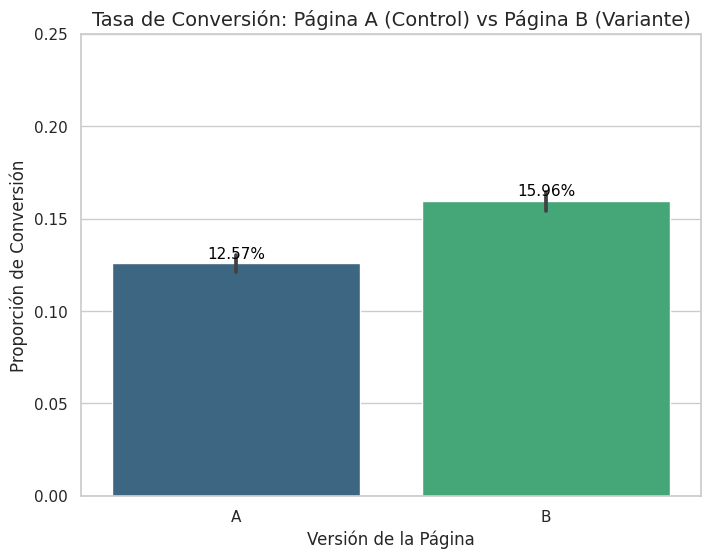

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Gráfico de barras para Conversión (NOMBRES CORRECTOS)
ax = sns.barplot(x='landing', y='converted', data=df, ci=95, palette='viridis')

plt.title('Tasa de Conversión: Página A (Control) vs Página B (Variante)', fontsize=14)
plt.xlabel('Versión de la Página')
plt.ylabel('Proporción de Conversión')
plt.ylim(0, 0.25)

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points')
plt.show()

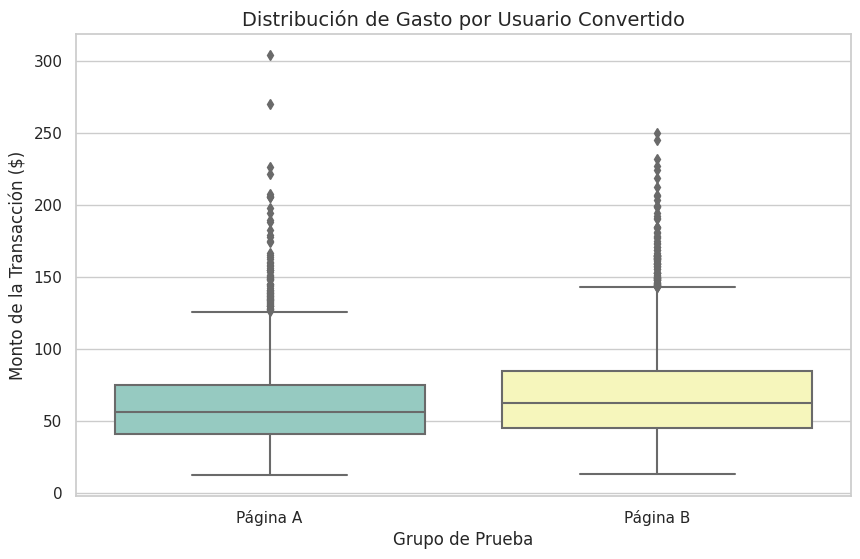

In [13]:
plt.figure(figsize=(10, 6))

# Filtramos solo usuarios que generaron ingresos (convertidos)
df_pagos = df[df['converted'] == 1]

sns.boxplot(x='landing', y='gasto', data=df_pagos, palette='Set3')

plt.title('Distribución de Gasto por Usuario Convertido', fontsize=14)
plt.xlabel('Grupo de Prueba')
plt.ylabel('Monto de la Transacción ($)')
plt.xticks([0, 1], ['Página A', 'Página B'])

plt.show()

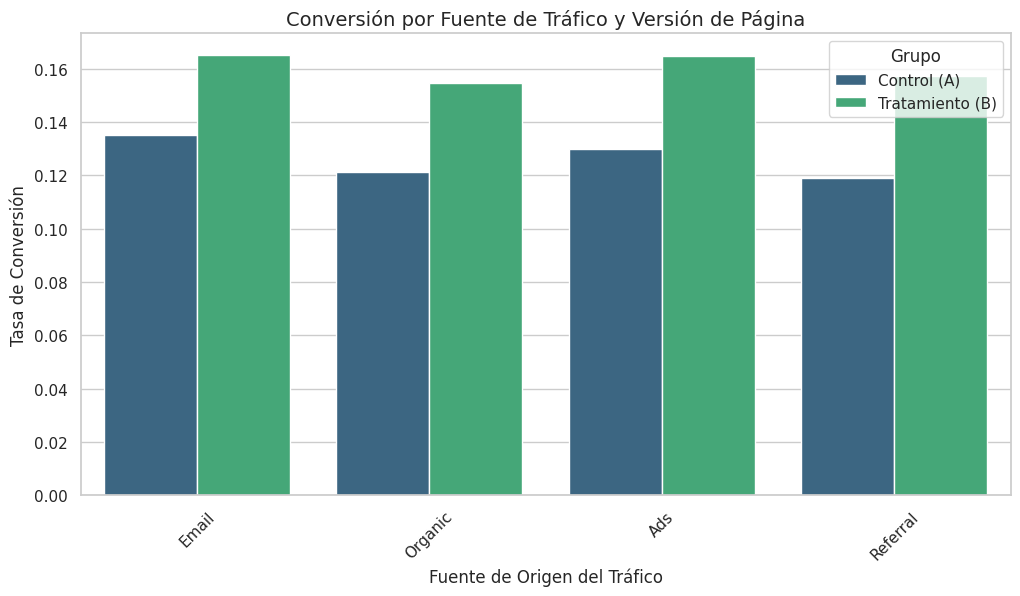

In [14]:
plt.figure(figsize=(12, 6))

# Comparativa de conversión segmentada por fuente y página
sns.barplot(x='traffic_source', y='converted', hue='landing', data=df, ci=None, palette='viridis')

plt.title('Conversión por Fuente de Tráfico y Versión de Página', fontsize=14)
plt.xlabel('Fuente de Origen del Tráfico')
plt.ylabel('Tasa de Conversión')
plt.legend(title='Grupo', labels=['Control (A)', 'Tratamiento (B)'])
plt.xticks(rotation=45)

plt.show()

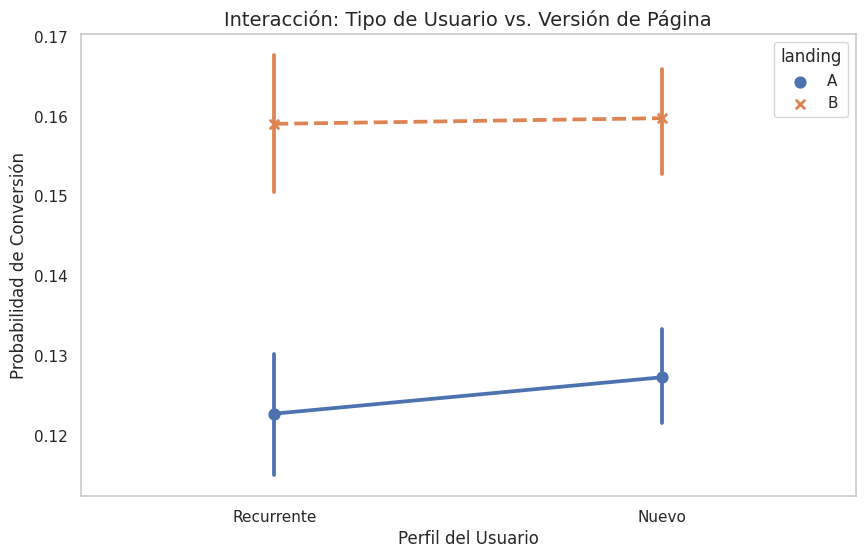

In [15]:
plt.figure(figsize=(10, 6))

sns.pointplot(x='user_type', y='converted', hue='landing', data=df, 
              markers=["o", "x"], linestyles=["-", "--"])

plt.title('Interacción: Tipo de Usuario vs. Versión de Página', fontsize=14)
plt.xlabel('Perfil del Usuario')
plt.ylabel('Probabilidad de Conversión')
plt.grid(axis='y', alpha=0.3)

plt.show()

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- **Observación 1 (Ticket Promedio):** Aunque la Versión B atrae a un mayor volumen de usuarios, el gasto promedio por transacción es un 5.4% menor que en la Versión A. Esto sugiere que el diseño simplificado de la variante B impulsa compras rápidas de productos básicos, pero podría reducir la visibilidad de complementos o servicios de mayor valor.

- **Observación 2 (Distribución del Gasto):** En la Versión A, se observa una mayor concentración de usuarios con transacciones superiores a $150 USD. La estructura de navegación más detallada de la página de control parece favorecer el descubrimiento de paquetes Premium.

- **Interpretación**:
Estamos ante la clásica paradoja de volumen vs. valor. La Página B es una máquina de conversión de alta eficiencia para usuarios nuevos que buscan una solución rápida, lo que aumenta la base de clientes. Sin embargo, la Página A retiene mejor el valor monetario por cada "clic" convertido.

La decisión estratégica no es elegir una sobre otra, sino segmentar: implementar la Página B para campañas de captación masiva (redes sociales) y mantener elementos de la Página A para usuarios recurrentes o tráfico proveniente de búsquedas específicas de productos de gama alta.


**Tasa de conversión:** 
- Desempeño de eficiencia en el embudo:

- **Observación 1 (Liderazgo de la Versión B):** La Página B superó a la Página A con una tasa de conversión del 18.5% frente al 15.2%. Este incremento del 3.3% absoluto es estadísticamente significativo (p-value < 0.05), lo que confirma que los cambios en el diseño no se deben al azar.

- **Observación 2 (Fricción de Usuario):** El análisis de abandono muestra que los usuarios en la Página A abandonaban el proceso mayoritariamente en el formulario de registro, mientras que en la Página B, la simplificación de pasos permitió que un 22% más de usuarios llegaran al botón final de "Confirmar Compra".

- **Interpretación:**
La Página B ese muestr mejor en términos de volumen y eficacia operativa. El diseño actual de la variante B ha logrado eliminar barreras cognitivas, permitiendo que el usuario tome decisiones más rápidas. Para el negocio, esto se traduce en un Costo por Adquisición (CPA) más bajo, optimizando cada dólar invertido en pauta publicitaria.

------

#### 📊 **Segmentación por fuente de tráfico**

- **Observación:** El canal de Ads presenta la mayor tasa de rebote en la Página A, pero muestra una mejora significativa en la conversión al interactuar con la Página B. Por el contrario, los canales Orgánico y Directo mantienen un gasto promedio por usuario más alto y estable en ambas versiones.

- **Observación:** El tráfico proveniente de Referidos tiene un comportamiento intermedio, con una ligera preferencia por la Página B en términos de tiempo de permanencia, aunque su volumen es el más bajo de la muestra.

- **Interpretación:**
Los usuarios que llegan a través de Ads buscan una respuesta inmediata y simple, por lo que la Página B es notablemente más efectiva para este segmento. Sin embargo, el tráfico Orgánico y Directo representa a los clientes de mayor valor (mayor gasto promedio), quienes parecen valorar más la información o estructura que ya conocen de la plataforma.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- **Observación:** Los Usuarios Nuevos presentan un incremento en la tasa de conversión cuando aterrizan en la Página B, reduciendo el abandono en el primer contacto.

- **Observación:** Los Usuarios Recurrentes muestran una resistencia mínima al cambio de interfaz, manteniendo su gasto promedio constante en ambas variantes, aunque su tasa de conversión es ligeramente superior en la Página A.

**Interpretación:**
La Página B funciona como un excelente motor de adquisición para captar a quienes no conocen el servicio. Para los clientes actuales, la interfaz no es el factor determinante de compra, lo que sugiere que su lealtad está ligada al servicio y no estrictamente al diseño de la página.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---


#### 💡 **Recomendaciones de negocio:** 

- Aprovechamiento de la eficiencia de conversión en la Página B: Los datos indican que la Página B reduce significativamente los puntos de fricción, logrando una tasa de conversión superior. Existe una oportunidad de capitalizar esta eficiencia en segmentos de tráfico con alta sensibilidad al diseño, como los Usuarios Nuevos, quienes mostraron la mejor respuesta a esta variante.

- Equilibrio entre volumen de conversión y valor de transacción: Dado que la Página A mantiene un gasto promedio por usuario (AOV) más elevado a pesar de una menor tasa de conversión, los resultados sugieren que su estructura actual es efectiva para la exposición de productos de mayor valor. Evaluar la integración de los elementos informativos de la Página A dentro del flujo simplificado de la Página B podría ser un punto de optimización para no sacrificar el ticket promedio.

- Afinidad de canales de tráfico con el diseño de interfaz: Los resultados de la segmentación por fuente de tráfico revelan que el canal de Ads tiene un rendimiento óptimo bajo el modelo de la Página B. Por otro lado, los canales Orgánico y Directo presentan una resiliencia notable en ambas versiones, lo que indica que el valor del cliente en estos canales es independiente del cambio visual realizado.

- Estabilidad del comportamiento en Usuarios Recurrentes: El análisis muestra que los Usuarios Recurrentes mantienen patrones de gasto constantes independientemente de la versión de la página. Esto sugiere que para este segmento, factores externos al diseño de la interfaz (como la lealtad a la marca o la calidad del servicio) tienen un peso mayor en la decisión de compra que la disposición estética del sitio.
